# 03 — Training runner, pre-configured: `c1_ce_s6out` (E2′ living-out)

A copy of the `03_train` template with `RUN` pre-set — open, run all,
no edits needed.

**Why this run exists (E2′, v5.2 §10.3):** the primary rotation tests on
S7 (laboratory — environment, day AND person unseen). This rotation
tests C1 on **S6 (living room, person P1 seen in train)** with S7 moved
into train: a second, different cross-domain regime for the C1 baseline,
and the input for replicating the §9 domain diagnostics on a train set
whose non-bedroom environment is the laboratory instead of the living
room. Config `c1_ce_s6out.yaml` is byte-identical to `c1_ce.yaml` except
`name`/`protocol`/`split_file` — same seed 42, same budget (~2.3 h).

**Prerequisite:** `splits/p2_living.json` frozen on Git (session
`01_s6out_split.ipynb`, committed and pushed) — asserted below.

Archive the executed copy under `notebooks/runs/` as
`YYYY-MM-DD_c1_ce_s6out.ipynb`, as for every run (cell at the bottom).


## Training curves

Per-epoch diagnostics read from the run's `history.csv` (§0.4). The
panels adapt to the run: train loss and throughput always; fused val
macro-F1 with the val-selected best epoch on CE runs; learning rate.
Re-run this cell any time — it re-reads the CSV, so it also works on a
resumed or still-running run.

Reminder for this rotation: the val macro-F1 here is a **5-class**
number (H, L and W absent from val, see the split session) and val is 6
traces — selection is noisy and NOT scale-comparable to p2_lab val
numbers, nor to the 8-class test macro-F1.


Mounted at /content/drive
run_dir: /content/drive/MyDrive/sharp_har_runs/C1_s6out | exists: True
history.csv: True


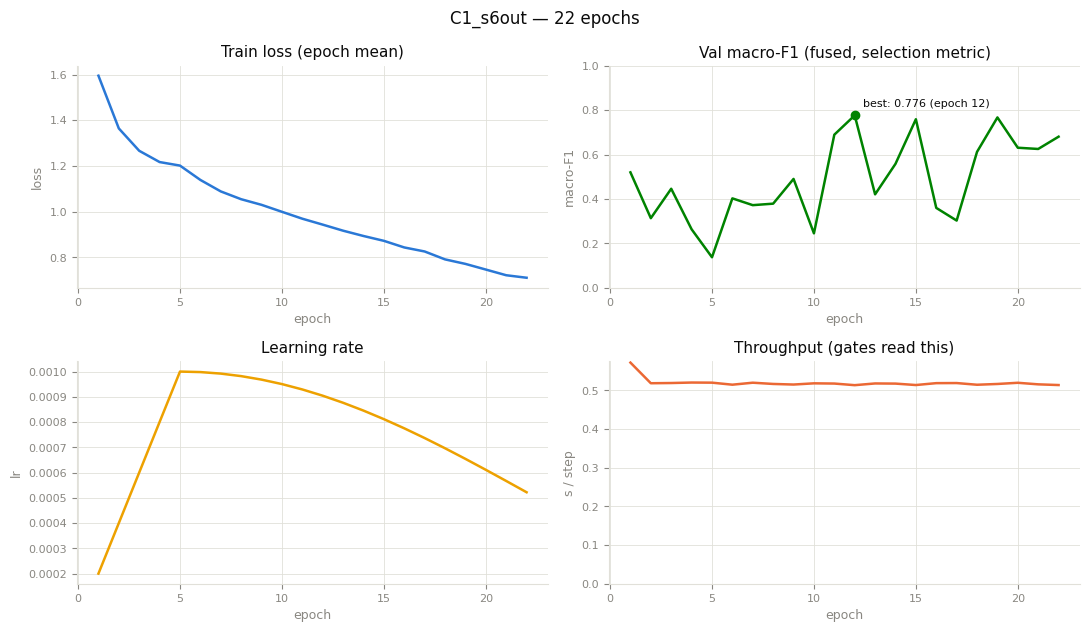

In [1]:
from pathlib import Path
import subprocess, sys

REPO_URL = "https://github.com/FilippoIsoni/sharp-har.git"

# Clone the repo (only sharp_har.viz is needed here) if not already present
cwd = Path.cwd().resolve()
if (cwd / "sharp_har").exists():
    REPO_DIR = cwd
elif (cwd.parent / "sharp_har").exists():
    REPO_DIR = cwd.parent
else:
    REPO_DIR = Path("/content/sharp-har")
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

!pip install -q -r {REPO_DIR}/requirements.txt
sys.path.insert(0, str(REPO_DIR))

from google.colab import drive
from sharp_har.utils import read_yaml
from sharp_har.viz import plot_history

drive.mount("/content/drive")

paths_cfg = read_yaml(REPO_DIR / "configs" / "paths.yaml")
CKPT_ROOT = Path(paths_cfg["ckpt_root"])
cfg = read_yaml(REPO_DIR / "configs" / "c1_ce_s6out.yaml")

run_dir = CKPT_ROOT / cfg["name"]        # -> /content/drive/MyDrive/sharp_har_runs/C1_s6out
print("run_dir:", run_dir, "| exists:", run_dir.exists())
print("history.csv:", (run_dir / "history.csv").exists())

plot_history(run_dir);


## Archiving the definitive run notebook

This notebook stays a **clean template** (outputs cleared on Git). The
executed copy of a real run is a measured artifact and is committed
verbatim, like the gate reports:

1. When the run (or a resumed segment) ends, download the executed
   notebook (`File → Download → .ipynb`) **with its outputs**.
2. Commit it under `notebooks/runs/` as `YYYY-MM-DD_<config>.ipynb`
   (e.g. `2026-07-18_c1_ce_s6out.ipynb`); add a `_partN` suffix if one
   run spans several resumed sessions. Never edit archived outputs.
3. The run's numeric artifacts still live in `ckpt_root/<name>/`
   (`history.csv`, `run_meta.json`, checkpoints) — the archived
   notebook is the human-readable record, not a data source.

See `notebooks/runs/README.md` for the full convention.
